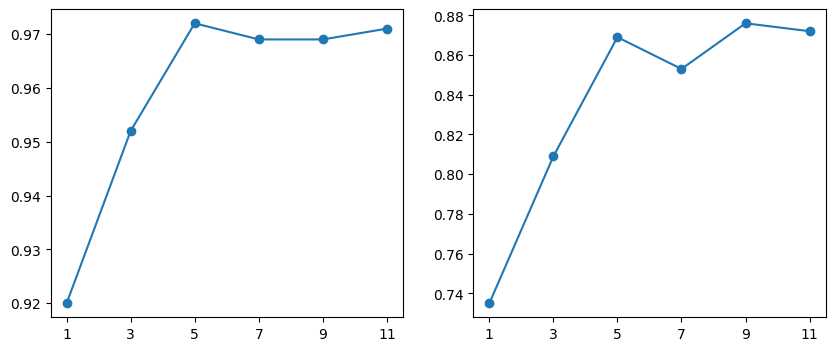

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
# 数据（假设数据以字符串形式给出）
data = """
multi-vr a=1, b=20, c=3, d=30, dim=1, pre_train_steps=10000, AUC=0.92, CSI=0.735, steps = 1300
multi-vr a=1, b=20, c=3, d=30, dim=3, pre_train_steps=10000, AUC=0.952, CSI=0.809, steps = 1250
multi-vr a=1, b=20, c=3, d=30, dim=5, pre_train_steps=10000, AUC=0.972, CSI=0.869, steps = 900
multi-vr a=1, b=20, c=3, d=30, dim=7, pre_train_steps=10000, AUC=0.969, CSI=0.853, steps = 1200
multi-vr a=1, b=20, c=3, d=30, dim=9, pre_train_steps=10000, AUC=0.969, CSI=0.876, steps = 1300
multi-vr a=1, b=20, c=3, d=30, dim=11, pre_train_steps=10000, AUC=0.971, CSI=0.872, steps = 1300
"""

# 提取数据
lines = data.strip().split("\n")
dim_vr_list = []
auc_list = []
csi_list = []

for line in lines:
    parts = line.split(", ")
    dim_vr = float(parts[4].split("=")[1])
    auc = float(parts[6].split("=")[1])
    csi = float(parts[7].split("=")[1])
    dim_vr_list.append(dim_vr)
    auc_list.append(auc)
    csi_list.append(csi)
import numpy as np
plt.subplot(121)
plt.plot(dim_vr_list,auc_list,'o-')
plt.xticks(np.arange(1, 12, step=2))
plt.subplot(122)
plt.plot(dim_vr_list,csi_list,'o-')
plt.xticks(np.arange(1, 12, step=2))
plt.savefig(f'./paper_related/multi_vr.png')
plt.savefig(f'./paper_related/multi_vr.pdf')

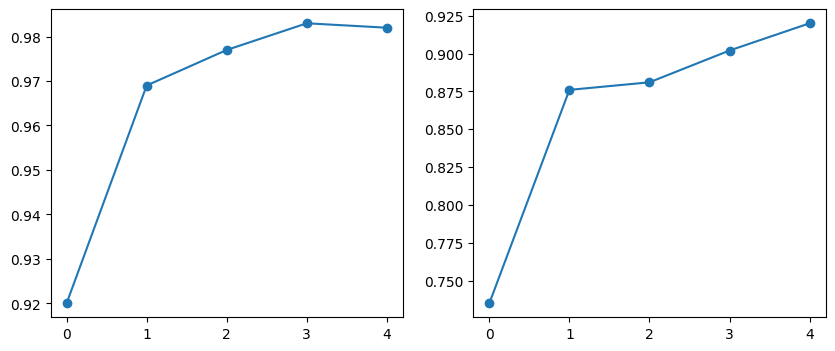

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,4))
# 数据（假设数据以字符串形式给出）
# """
# multi-vr a=1, b=20, c=3, d=30, dim=1, pre_train_steps=10000, AUC=0.92, CSI=0.735, steps = 1300
# multi-vr a=1, b=20, c=3, d=30, dim=9, pre_train_steps=10000, AUC=0.969, CSI=0.876, steps = 1300
# cnn, attn_loc_ = 0,a_dim = 5, b_dim = 9, c_dim = 15,b=30, d=40, f_ = 500, if_load = 1, pre_train_steps=5000,  AUC=0.977, CSI=0.881, steps = 2600
# cnn-attn, attn_loc_ = 4,a_dim = 5, b_dim = 9, c_dim = 15,b=30, d=40, f_ = 500, if_load = 1, pre_train_steps=5000,  AUC=0.983, CSI=0.902, steps = 3350
# cnn-attn-pos, attn_loc_ = 4,a_dim = 5, b_dim = 9, c_dim = 15,b=30, d=40, f_ = 500, if_load = 1, pre_train_steps=5000,  AUC=0.982, CSI=0.92, steps = 2900
# """

dim_vr_list = [0,1,2,3,4]
auc_list = [0.92,0.969,0.977,0.983,0.982]
csi_list = [0.735,0.876,0.881,0.902,0.92]
import numpy as np
plt.subplot(121)
plt.plot(dim_vr_list,auc_list,'o-')
# plt.xticks(np.arange(1, 12, step=2))
plt.subplot(122)
plt.plot(dim_vr_list,csi_list,'o-')
# plt.xticks(np.arange(1, 12, step=2))
plt.savefig(f'./paper_related/ablation.png')
plt.savefig(f'./paper_related/ablation.pdf')

In [ ]:
import pandas as pd

# 读取数据
lines = []
with open('output_attn_new.txt', 'r') as f:
    for line in f:
        if line == '\n':
            continue
        parts = line.strip().split(',')
        model = parts[0].strip()
        attn_loc = parts[1].split('=')[1].strip()
        a_dim = int(parts[2].split('=')[1].strip())
        b_dim = int(parts[3].split('=')[1].strip())
        c_dim = int(parts[4].split('=')[1].strip())
        b = int(parts[5].split('=')[1].strip())
        d = int(parts[6].split('=')[1].strip())
        f_ = int(parts[7].split('=')[1].strip())
        if_load = int(parts[8].split('=')[1].strip())
        pre_train_steps = int(parts[9].split('=')[1].strip())
        auc = float(parts[10].split('=')[1].strip())
        csi = float(parts[11].split('=')[1].strip())
        steps = int(parts[12].split('=')[1].strip())
        
        lines.append({
            'model': model,
            'attn_loc': attn_loc,
            'a_dim': a_dim,
            'b_dim': b_dim,
            'c_dim': c_dim,
            'b': b,
            'd': d,
            'f_': f_,
            'if_load': if_load,
            'pre_train_steps': pre_train_steps,
            'AUC': auc,
            'CSI': csi,
            'steps': steps
        })

df = pd.DataFrame(lines)

# 计算 AUC+CSI 总和
df['AUC_CSI'] = df['AUC'] + df['CSI']

# 筛选条件：attn_loc 为 4 时（因为你的对比是在同一个注意力位置下）
results = []

# 遍历所有参数组合
for (a_dim, b_dim, c_dim, b, d, f_, if_load, pre_train_steps), group in df.groupby(['a_dim', 'b_dim', 'c_dim', 'b', 'd', 'f_', 'if_load', 'pre_train_steps']):
    # 找出三种模型
    cnn = group[group['model'] == 'cnn']
    attn = group[(group['model'] == 'cnn-attn') & (group['attn_loc'] == '4')]
    attn_pos = group[(group['model'] == 'cnn-attn-pos') & (group['attn_loc'] == '4')]
    
    if len(cnn) > 0 and len(attn) > 0 and len(attn_pos) > 0 :
        auc_csi_cnn = cnn['AUC_CSI'].values[0]
        auc_csi_attn = attn['AUC_CSI'].values[0]
        auc_csi_attn_pos = attn_pos['AUC_CSI'].values[0]
        
        # 检查是否满足：cnn < attn < attn_pos
        if auc_csi_cnn < auc_csi_attn < auc_csi_attn_pos:
            results.append({
                'a_dim': a_dim,
                'b_dim': b_dim,
                'c_dim': c_dim,
                'b': b,
                'd': d,
                'f_': f_,
                'if_load': if_load,
                'pre_train_steps': pre_train_steps,
                'AUC+CSI_cnn': auc_csi_cnn,
                'AUC+CSI_attn': auc_csi_attn,
                'AUC+CSI_attn_pos': auc_csi_attn_pos,
                'AUC_cnn': cnn['AUC'].values[0],
                'CSI_cnn': cnn['CSI'].values[0],
                'AUC_attn': attn['AUC'].values[0],
                'CSI_attn': attn['CSI'].values[0],
                'AUC_attn_pos': attn_pos['AUC'].values[0],
                'CSI_attn_pos': attn_pos['CSI'].values[0]
            })

# 输出结果
if results:
    results_df = pd.DataFrame(results)
    print("✅ 找到符合 cnn < attn < attn_pos 的参数组合：")
    print(results_df.to_string(index=False))
    print(f"\n总共找到 {len(results_df)} 组参数。")
else:
    print("❌ 没有找到完全符合条件的参数组合。")

✅ 找到符合 cnn < attn < attn_pos 的参数组合：
 a_dim  b_dim  c_dim  b  d   f_  if_load  pre_train_steps  AUC+CSI_cnn  AUC+CSI_attn  AUC+CSI_attn_pos  AUC_cnn  CSI_cnn  AUC_attn  CSI_attn  AUC_attn_pos  CSI_attn_pos
     5      9     15 20 30  500        1             5000        1.852         1.855             1.889    0.978    0.874     0.979     0.876         0.984         0.905
     5      9     15 20 30 1000        0             5000        1.859         1.879             1.898    0.978    0.881     0.979     0.900         0.983         0.915
     5      9     15 20 30 1000        1             5000        1.852         1.855             1.905    0.978    0.874     0.979     0.876         0.984         0.921
     5      9     15 30 40  500        1             5000        1.858         1.885             1.902    0.977    0.881     0.983     0.902         0.982         0.920
     5      9     15 30 40 1000        0             5000        1.851         1.877             1.892    0.978    0.87

In [ ]:
# 另一个版本：使用每个模型的最佳性能进行比较
results_best = []

# 遍历所有参数组合（不包括 if_load）
for (a_dim, b_dim, c_dim, b, d, f_, pre_train_steps), group in df.groupby(['a_dim', 'b_dim', 'c_dim', 'b', 'd', 'f_', 'pre_train_steps']):
    # 找出三种模型（不考虑 if_load）
    cnn = group[group['model'] == 'cnn']
    attn = group[(group['model'] == 'cnn-attn') & (group['attn_loc'] == '4')]
    attn_pos = group[(group['model'] == 'cnn-attn-pos') & (group['attn_loc'] == '4')]
    
    # 检查是否每个模型至少有一个结果
    if len(cnn) > 0 and len(attn) > 0 and len(attn_pos) > 0:
        # 获取每个模型的最高性能
        auc_csi_cnn_best = cnn['AUC_CSI'].max()
        auc_csi_attn_best = attn['AUC_CSI'].max()
        auc_csi_attn_pos_best = attn_pos['AUC_CSI'].max()
        
        # 检查是否满足：cnn < attn < attn_pos
        if auc_csi_cnn_best < auc_csi_attn_best < auc_csi_attn_pos_best:
            # 找出对应的记录
            best_cnn = cnn[cnn['AUC_CSI'] == auc_csi_cnn_best].iloc[0]
            best_attn = attn[attn['AUC_CSI'] == auc_csi_attn_best].iloc[0]
            best_attn_pos = attn_pos[attn_pos['AUC_CSI'] == auc_csi_attn_pos_best].iloc[0]
            
            results_best.append({
                'a_dim': a_dim,
                'b_dim': b_dim,
                'c_dim': c_dim,
                'b': b,
                'd': d,
                'f_': f_,
                'pre_train_steps': pre_train_steps,
                'if_load_cnn': best_cnn['if_load'],
                'if_load_attn': best_attn['if_load'],
                'if_load_attn_pos': best_attn_pos['if_load'],
                'AUC+CSI_cnn': auc_csi_cnn_best,
                'AUC+CSI_attn': auc_csi_attn_best,
                'AUC+CSI_attn_pos': auc_csi_attn_pos_best,
                'AUC_cnn': best_cnn['AUC'],
                'CSI_cnn': best_cnn['CSI'],
                'AUC_attn': best_attn['AUC'],
                'CSI_attn': best_attn['CSI'],
                'AUC_attn_pos': best_attn_pos['AUC'],
                'CSI_attn_pos': best_attn_pos['CSI']
            })

# 输出最佳性能结果
if results_best:
    results_best_df = pd.DataFrame(results_best)
    print("\n✅ 找到符合 cnn < attn < attn_pos 的参数组合（使用每个模型的最佳性能）：")
    print(results_best_df.to_string(index=False))
    print(f"\n总共找到 {len(results_best_df)} 组参数。")
else:
    print("\n❌ 没有找到使用最佳性能比较的符合条件的参数组合。")


✅ 找到符合 cnn < attn < attn_pos 的参数组合（使用每个模型的最佳性能）：
 a_dim  b_dim  c_dim  b  d   f_  pre_train_steps  if_load_cnn  if_load_attn  if_load_attn_pos  AUC+CSI_cnn  AUC+CSI_attn  AUC+CSI_attn_pos  AUC_cnn  CSI_cnn  AUC_attn  CSI_attn  AUC_attn_pos  CSI_attn_pos
     5      9     15 20 30  500             5000            0             0                 1        1.859         1.879             1.889    0.978    0.881     0.979     0.900         0.984         0.905
     5      9     15 20 30 1000             5000            0             0                 1        1.859         1.879             1.905    0.978    0.881     0.979     0.900         0.984         0.921
     5      9     15 30 40  500             5000            1             1                 1        1.858         1.885             1.902    0.977    0.881     0.983     0.902         0.982         0.920
     5      9     15 30 40 1000             5000            1             1                 1        1.858         1.885          

数据解析完成，开始生成图表...
总数据条数: 84

前5条解析后的数据:
第1条: {'model': 'cnn', 'attn_loc_': 0, 'a_dim': 3, 'b_dim': 11, 'c_dim': 11, 'b': 20, 'd': 30, 'f_': 100, 'if_load': 0, 'pre_train_steps': 5000, 'AUC': 0.975, 'CSI': 0.859, 'steps': 2250}
第2条: {'model': 'cnn', 'attn_loc_': 0, 'a_dim': 3, 'b_dim': 11, 'c_dim': 11, 'b': 20, 'd': 30, 'f_': 1000, 'if_load': 0, 'pre_train_steps': 5000, 'AUC': 0.975, 'CSI': 0.859, 'steps': 2250}
第3条: {'model': 'cnn', 'attn_loc_': 0, 'a_dim': 3, 'b_dim': 11, 'c_dim': 11, 'b': 20, 'd': 30, 'f_': 100, 'if_load': 1, 'pre_train_steps': 5000, 'AUC': 0.97, 'CSI': 0.867, 'steps': 3400}
第4条: {'model': 'cnn', 'attn_loc_': 0, 'a_dim': 3, 'b_dim': 11, 'c_dim': 11, 'b': 20, 'd': 30, 'f_': 1000, 'if_load': 1, 'pre_train_steps': 5000, 'AUC': 0.97, 'CSI': 0.867, 'steps': 3400}
第5条: {'model': 'cnn-attn', 'attn_loc_': 4, 'a_dim': 3, 'b_dim': 11, 'c_dim': 11, 'b': 20, 'd': 30, 'f_': 100, 'if_load': 0, 'pre_train_steps': 5000, 'AUC': 0.967, 'CSI': 0.867, 'steps': 2300}

生成图表: if_load=1, met

d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:167: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from current font

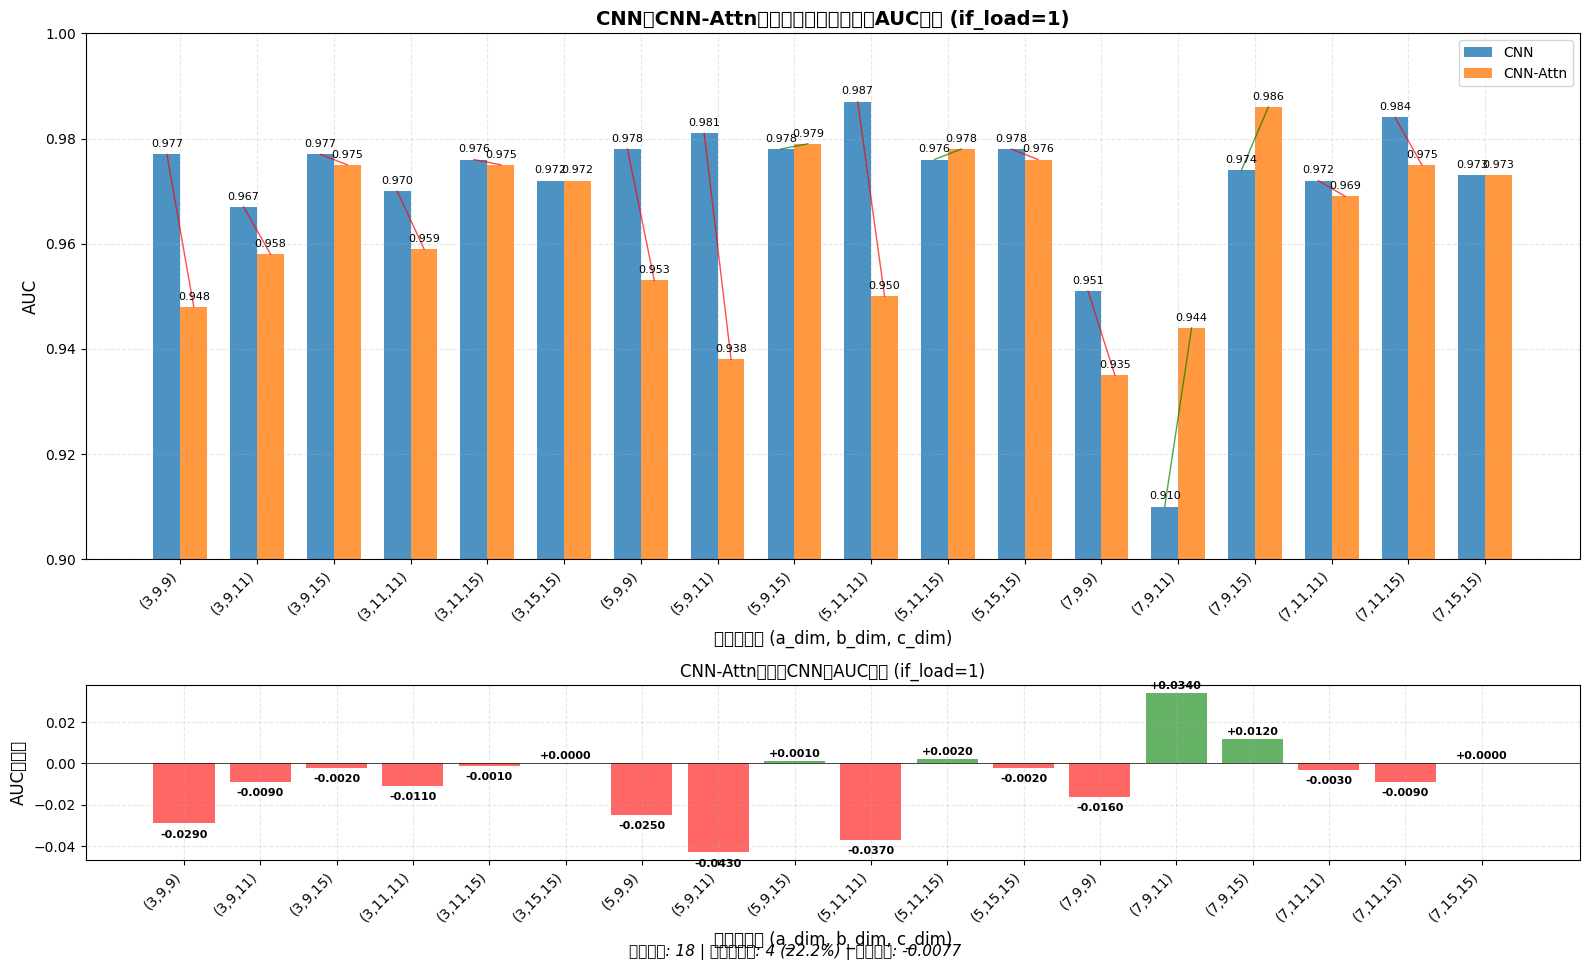

性能对比统计信息 (if_load=1, metric=AUC):
总配置对数: 18
CNN-Attn优于CNN的配置数: 4 (22.2%)
AUC平均提升值: -0.0077
最大提升: 0.0340
最大下降: -0.0430

提升最显著的配置 (if_load=1, metric=AUC):
  (7,9,11): +0.0340
  (7,9,15): +0.0120
  (5,11,15): +0.0020
  (5,9,15): +0.0010

生成图表: if_load=1, metric=CSI


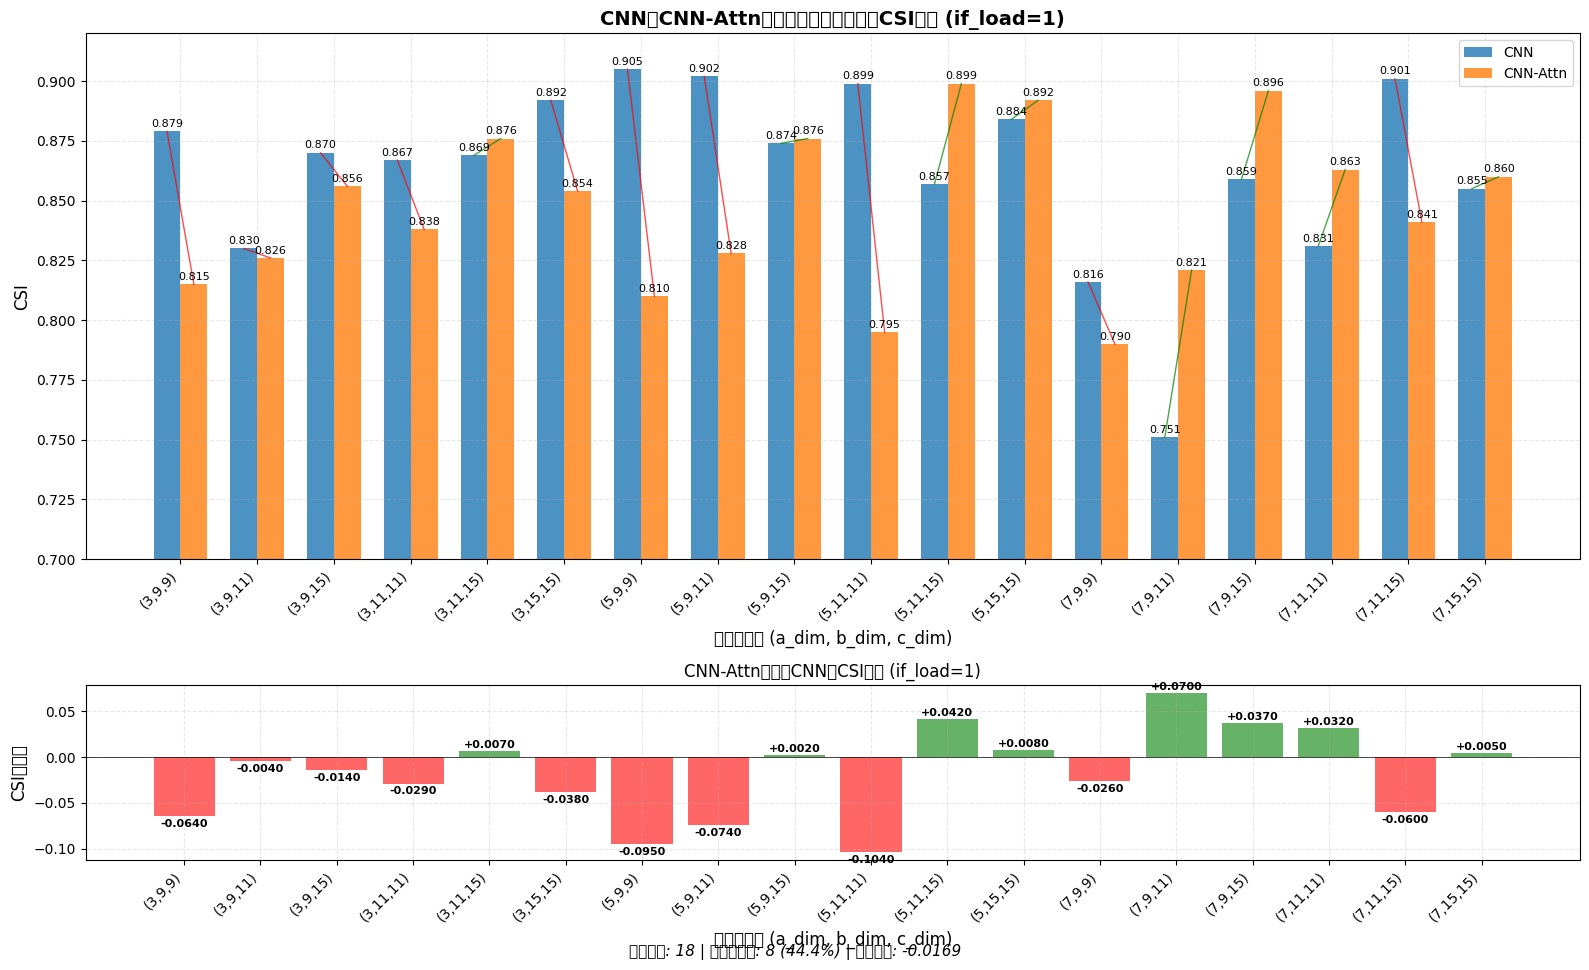

性能对比统计信息 (if_load=1, metric=CSI):
总配置对数: 18
CNN-Attn优于CNN的配置数: 8 (44.4%)
CSI平均提升值: -0.0169
最大提升: 0.0700
最大下降: -0.1040

提升最显著的配置 (if_load=1, metric=CSI):
  (7,9,11): +0.0700
  (5,11,15): +0.0420
  (7,9,15): +0.0370
  (7,11,11): +0.0320
  (5,15,15): +0.0080

图表生成完成总结:
if_load=1, AUC: 4/18 (22.2%) 配置有提升，平均提升: -0.0077
if_load=1, CSI: 8/18 (44.4%) 配置有提升，平均提升: -0.0169


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def parse_data(file_path):
    """解析数据文件"""
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # 初始化参数字典
            params = {}
            
            # 首先检查模型类型
            if line.startswith('cnn-attn'):
                params['model'] = 'cnn-attn'
                line = line.replace('cnn-attn,', '', 1)
            elif line.startswith('cnn'):
                params['model'] = 'cnn'
                line = line.replace('cnn,', '', 1)
            else:
                continue  # 跳过不符合格式的行
            
            # 解析剩余的参数
            parts = line.split(',')
            for part in parts:
                part = part.strip()
                if '=' in part:
                    key, value = part.split('=')
                    key = key.strip()
                    
                    # 处理不同的键
                    if key in ['attn_loc_', 'a_dim', 'b_dim', 'c_dim', 'b', 'd', 'f_', 'if_load', 'pre_train_steps', 'steps']:
                        params[key] = int(value)
                    elif key in ['AUC', 'CSI']:
                        params[key] = float(value)
            
            data.append(params)
    
    return data

def create_comparison_charts(data, if_load_value, metric='AUC', save_path=None):
    """创建指定if_load值和指标的对比图"""
    
    # 过滤指定if_load的数据
    filtered_data = [item for item in data if item['if_load'] == if_load_value]
    
    # 按配置分组数据
    config_groups = {}
    for item in filtered_data:
        key = (item['a_dim'], item['b_dim'], item['c_dim'])
        if key not in config_groups:
            config_groups[key] = {'cnn': None, 'cnn-attn': None}
        
        # 确保模型字段存在且正确
        if 'model' in item:
            model_type = item['model']
            if model_type in ['cnn', 'cnn-attn']:
                config_groups[key][model_type] = item[metric]
    
    # 过滤出既有cnn又有cnn-attn的配置
    complete_configs = []
    for key, values in config_groups.items():
        if values['cnn'] is not None and values['cnn-attn'] is not None:
            complete_configs.append((key, values))
    
    # 按配置名称排序
    complete_configs.sort(key=lambda x: (x[0][0], x[0][1], x[0][2]))
    
    if not complete_configs:
        print(f"if_load={if_load_value} 且 metric={metric} 没有完整的数据对")
        return None
    
    # 准备绘图数据
    config_labels = [f"({a},{b},{c})" for (a,b,c), _ in complete_configs]
    cnn_values = [values['cnn'] for _, values in complete_configs]
    cnn_attn_values = [values['cnn-attn'] for _, values in complete_configs]
    
    # 计算提升值
    improvements = [cnn_attn - cnn for cnn, cnn_attn in zip(cnn_values, cnn_attn_values)]
    
    # 创建图表
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    x = np.arange(len(config_labels))
    bar_width = 0.35
    
    # 设置颜色
    cnn_color = '#1f77b4'  # 蓝色
    cnn_attn_color = '#ff7f0e'  # 橙色
    
    # 主图：性能对比条形图
    bars1 = ax1.bar(x - bar_width/2, cnn_values, bar_width, 
                    label='CNN', color=cnn_color, alpha=0.8)
    bars2 = ax1.bar(x + bar_width/2, cnn_attn_values, bar_width, 
                    label='CNN-Attn', color=cnn_attn_color, alpha=0.8)
    
    # 在条形上添加数值标签
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 添加连接线显示提升
    for i in range(len(x)):
        y1 = cnn_values[i]
        y2 = cnn_attn_values[i]
        if y2 > y1:
            ax1.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y1, y2], 
                    'g-', linewidth=1, alpha=0.7)
        elif y2 < y1:
            ax1.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y1, y2], 
                    'r-', linewidth=1, alpha=0.7)
    
    ax1.set_xlabel('卷积核配置 (a_dim, b_dim, c_dim)', fontsize=12)
    ax1.set_ylabel(metric, fontsize=12)
    
    # 设置标题和Y轴范围
    if metric == 'AUC':
        title = f'CNN与CNN-Attn在不同卷积核配置下的{metric}对比 (if_load={if_load_value})'
        ylim_min = 0.9
        ylim_max = 1.0
    else:  # CSI
        title = f'CNN与CNN-Attn在不同卷积核配置下的{metric}对比 (if_load={if_load_value})'
        ylim_min = 0.7
        ylim_max = 0.92
    
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(config_labels, rotation=45, ha='right', fontsize=10)
    ax1.set_ylim([ylim_min, ylim_max])
    ax1.legend()
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 子图：性能提升值
    colors = ['green' if imp >= 0 else 'red' for imp in improvements]
    bars_imp = ax2.bar(x, improvements, color=colors, alpha=0.6)
    
    # 在提升条形上添加数值标签
    for i, imp in enumerate(improvements):
        va = 'bottom' if imp >= 0 else 'top'
        y_offset = 0.001 if imp >= 0 else -0.003
        ax2.text(i, imp + y_offset, 
                f'{imp:+.4f}', ha='center', va=va, 
                fontsize=8, fontweight='bold')
    
    ax2.set_xlabel('卷积核配置 (a_dim, b_dim, c_dim)', fontsize=12)
    ax2.set_ylabel(f'{metric}提升值', fontsize=12)
    ax2.set_title(f'CNN-Attn相对于CNN的{metric}提升 (if_load={if_load_value})', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(config_labels, rotation=45, ha='right', fontsize=10)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # 添加统计信息
    total_configs = len(improvements)
    positive_improvements = sum(1 for imp in improvements if imp > 0)
    avg_improvement = np.mean(improvements)
    
    stats_text = f'总配置数: {total_configs} | 提升配置数: {positive_improvements} ({positive_improvements/total_configs*100:.1f}%) | 平均提升: {avg_improvement:.4f}'
    fig.suptitle(stats_text, fontsize=11, y=0.02, style='italic')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # 打印详细统计信息
    print("="*60)
    print(f"性能对比统计信息 (if_load={if_load_value}, metric={metric}):")
    print("="*60)
    print(f"总配置对数: {total_configs}")
    print(f"CNN-Attn优于CNN的配置数: {positive_improvements} ({positive_improvements/total_configs*100:.1f}%)")
    print(f"{metric}平均提升值: {avg_improvement:.4f}")
    print(f"最大提升: {max(improvements):.4f}")
    print(f"最大下降: {min(improvements):.4f}")
    
    # 列出提升最显著的几个配置
    print(f"\n提升最显著的配置 (if_load={if_load_value}, metric={metric}):")
    sorted_indices = np.argsort(improvements)[::-1][:5]  # 前5个
    for idx in sorted_indices:
        if improvements[idx] > 0:
            config = complete_configs[idx][0]
            print(f"  ({config[0]},{config[1]},{config[2]}): +{improvements[idx]:.4f}")
    
    return complete_configs, cnn_values, cnn_attn_values, improvements

# 主程序
def main():
    # 解析数据
    data = parse_data('.\outputs\multi_scale3.txt')
    
    print("数据解析完成，开始生成图表...")
    print(f"总数据条数: {len(data)}")
    
    # 检查解析结果
    print("\n前5条解析后的数据:")
    for i, item in enumerate(data[:5]):
        print(f"第{i+1}条: {item}")
    
    # 分别绘制四张图
    metrics = ['AUC', 'CSI']
    if_load_values = [1]#0, 
    
    results = {}
    
    for if_load_val in if_load_values:
        for metric in metrics:
            print(f"\n{'='*80}")
            print(f"生成图表: if_load={if_load_val}, metric={metric}")
            print('='*80)
            
            result = create_comparison_charts(
                data, 
                if_load_value=if_load_val, 
                metric=metric
            )#,save_path=f'comparison_ifload{if_load_val}_{metric}.png'
            
            if result:
                results[(if_load_val, metric)] = result
    
    # 打印总结信息
    print("\n" + "="*80)
    print("图表生成完成总结:")
    print("="*80)
    for (if_load_val, metric) in results:
        complete_configs, cnn_values, cnn_attn_values, improvements = results[(if_load_val, metric)]
        avg_imp = np.mean(improvements)
        pos_count = sum(1 for imp in improvements if imp > 0)
        total = len(improvements)
        print(f"if_load={if_load_val}, {metric}: {pos_count}/{total} ({pos_count/total*100:.1f}%) 配置有提升，平均提升: {avg_imp:.4f}")
    
    return results

# 运行主程序
if __name__ == "__main__":
    results = main()

数据解析完成...
总数据条数: 84

选择的卷积核配置: [(3, 9, 11), (3, 9, 15), (3, 11, 11), (7, 9, 11), (7, 11, 11), (7, 9, 15)]

生成图表: if_load=0, metric=AUC

所有选择的配置对比结果 (if_load=0, metric=AUC):
------------------------------------------------------------
配置(3,9,11): CNN=0.965, CNN-Attn=0.970, 提升=+0.0050 ↑
配置(3,9,15): CNN=0.980, CNN-Attn=0.974, 提升=-0.0060 ↓
配置(3,11,11): CNN=0.975, CNN-Attn=0.967, 提升=-0.0080 ↓
配置(7,9,11): CNN=0.909, CNN-Attn=0.944, 提升=+0.0350 ↑
配置(7,11,11): CNN=0.973, CNN-Attn=0.975, 提升=+0.0020 ↑
配置(7,9,15): CNN=0.970, CNN-Attn=0.987, 提升=+0.0170 ↑

生成图表: if_load=0, metric=CSI

所有选择的配置对比结果 (if_load=0, metric=CSI):
------------------------------------------------------------
配置(3,9,11): CNN=0.840, CNN-Attn=0.865, 提升=+0.0250 ↑
配置(3,9,15): CNN=0.893, CNN-Attn=0.851, 提升=-0.0420 ↓
配置(3,11,11): CNN=0.859, CNN-Attn=0.867, 提升=+0.0080 ↑
配置(7,9,11): CNN=0.750, CNN-Attn=0.795, 提升=+0.0450 ↑
配置(7,11,11): CNN=0.834, CNN-Attn=0.859, 提升=+0.0250 ↑
配置(7,9,15): CNN=0.847, CNN-Attn=0.899, 提升=+0.0520 ↑


d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:240: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:240: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:240: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:240: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:240: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from current font.
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py:241: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from current font


图表生成完成总结:
if_load=0, AUC: 4/6 (66.7%) 配置有提升，平均提升: 0.0075,性能波动：std(CNN)-std(CNN-ATTN) = 0.011141694843720932
if_load=0, CSI: 5/6 (83.3%) 配置有提升，平均提升: 0.0188,性能波动：std(CNN)-std(CNN-ATTN) = 0.01230316715904899


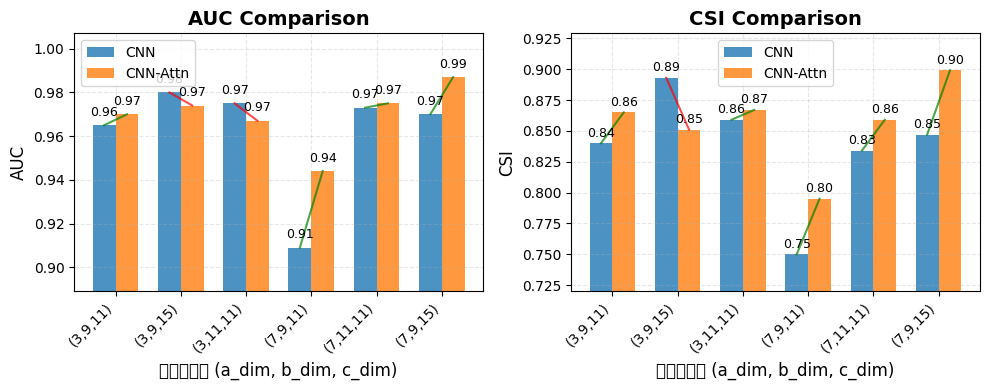

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def parse_data(file_path):
    """解析数据文件"""
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # 初始化参数字典
            params = {}
            
            # 首先检查模型类型
            if line.startswith('cnn-attn'):
                params['model'] = 'cnn-attn'
                line = line.replace('cnn-attn,', '', 1)
            elif line.startswith('cnn'):
                params['model'] = 'cnn'
                line = line.replace('cnn,', '', 1)
            else:
                continue  # 跳过不符合格式的行
            
            # 解析剩余的参数
            parts = line.split(',')
            for part in parts:
                part = part.strip()
                if '=' in part:
                    key, value = part.split('=')
                    key = key.strip()
                    
                    # 处理不同的键
                    if key in ['attn_loc_', 'a_dim', 'b_dim', 'c_dim', 'b', 'd', 'f_', 'if_load', 'pre_train_steps', 'steps']:
                        params[key] = int(value)
                    elif key in ['AUC', 'CSI']:
                        params[key] = float(value)
            
            data.append(params)
    
    return data

def create_filtered_comparison_charts(data, if_load_value, selected_configs,ax,  metric='AUC', save_path=None):
    """创建指定卷积核组合的对比图"""
    
    # 过滤指定if_load的数据
    filtered_data = [item for item in data if item['if_load'] == if_load_value]
    
    # 按配置分组数据
    config_groups = {}
    for item in filtered_data:
        key = (item['a_dim'], item['b_dim'], item['c_dim'])
        
        # 只处理选择的配置
        if key not in selected_configs:
            continue
            
        if key not in config_groups:
            config_groups[key] = {'cnn': None, 'cnn-attn': None}
        
        # 确保模型字段存在且正确
        if 'model' in item:
            model_type = item['model']
            if model_type in ['cnn', 'cnn-attn']:
                config_groups[key][model_type] = item[metric]
    
    # 过滤出既有cnn又有cnn-attn的配置
    complete_configs = []
    for key, values in config_groups.items():
        if values['cnn'] is not None and values['cnn-attn'] is not None:
            complete_configs.append((key, values))
    
    # 按选择的配置顺序排序
    def config_sort_key(item):
        key = item[0]
        if key in selected_configs:
            return (selected_configs.index(key), key)
        return (len(selected_configs), key)
    
    complete_configs.sort(key=config_sort_key)
    
    if not complete_configs:
        print(f"if_load={if_load_value}, metric={metric}, 选择的配置中没有完整的数据对")
        return None
    
    # 准备绘图数据
    config_labels = [f"({a},{b},{c})" for (a,b,c), _ in complete_configs]
    cnn_values = [values['cnn'] for _, values in complete_configs]
    cnn_attn_values = [values['cnn-attn'] for _, values in complete_configs]
    
    # 计算提升值
    improvements = [cnn_attn - cnn for cnn, cnn_attn in zip(cnn_values, cnn_attn_values)]
    
    # 创建图表
   
    
    x = np.arange(len(config_labels))
    bar_width = 0.35
    
    # 设置颜色
    cnn_color = '#1f77b4'  # 蓝色
    cnn_attn_color = '#ff7f0e'  # 橙色
    
    # 主图：性能对比条形图
    bars1 = ax.bar(x - bar_width/2, cnn_values, bar_width, 
                    label='CNN', color=cnn_color, alpha=0.8)
    bars2 = ax.bar(x + bar_width/2, cnn_attn_values, bar_width, 
                    label='CNN-Attn', color=cnn_attn_color, alpha=0.8)
    
    # 在条形上添加数值标签
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    # 添加连接线显示提升
    for i in range(len(x)):
        y1 = cnn_values[i]
        y2 = cnn_attn_values[i]
        if y2 > y1:
            ax.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y1, y2], 
                    'g-', linewidth=1.5, alpha=0.7)
        elif y2 < y1:
            ax.plot([x[i] - bar_width/2, x[i] + bar_width/2], [y1, y2], 
                    'r-', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('卷积核配置 (a_dim, b_dim, c_dim)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    
    # 设置标题和Y轴范围
    if metric == 'AUC':
        title = f'{metric} Comparison'
        ylim_min = min(min(cnn_values), min(cnn_attn_values)) - 0.02
        ylim_max = max(max(cnn_values), max(cnn_attn_values)) + 0.02
    else:  # CSI
        title = f'{metric} Comparison'
        ylim_min = min(min(cnn_values), min(cnn_attn_values)) - 0.03
        ylim_max = max(max(cnn_values), max(cnn_attn_values)) + 0.03
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(config_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylim([ylim_min, ylim_max])
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')

    # 添加统计信息
    total_configs = len(improvements)
    positive_improvements = sum(1 for imp in improvements if imp > 0)
    avg_improvement = np.mean(improvements)
    
    stats_text = f'选择的配置数: {total_configs} | 提升配置数: {positive_improvements} ({positive_improvements/total_configs*100:.1f}%) | 平均提升: {avg_improvement:.4f}'
    # fig.suptitle(stats_text, fontsize=11, y=0.02, style='italic')
    

    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    
    
    
    # 显示所有选择的配置的对比结果
    print(f"\n所有选择的配置对比结果 (if_load={if_load_value}, metric={metric}):")
    print("-" * 60)
    for i, (config, values) in enumerate(complete_configs):
        cnn_val = values['cnn']
        cnn_attn_val = values['cnn-attn']
        imp = cnn_attn_val - cnn_val
        status = "↑" if imp > 0 else ("↓" if imp < 0 else "=")
        color = "32" if imp > 0 else ("31" if imp < 0 else "33")  # 绿色/红色/黄色
        print(f"配置({config[0]},{config[1]},{config[2]}): CNN={cnn_val:.3f}, CNN-Attn={cnn_attn_val:.3f}, 提升=\033[{color}m{imp:+.4f}\033[0m {status}")
    
    return complete_configs, cnn_values, cnn_attn_values, improvements

# 主程序
def main():
    # 解析数据
    data = parse_data('.\outputs\multi_scale3.txt')
    
    print("数据解析完成...")
    print(f"总数据条数: {len(data)}")
    
    # 检查所有可用的配置
    all_configs = set()
    for item in data:
        all_configs.add((item['a_dim'], item['b_dim'], item['c_dim']))
    
    
    # 定义你想要绘制的特定卷积核组合
    selected_configs = [
        (3, 9, 11),
        (3, 9, 15),
        (3, 11, 11),
        (7, 9, 11),
        (7, 11, 11),
        (7, 9, 15)
    ]
    
    print(f"\n选择的卷积核配置: {selected_configs}")
    
    # 检查选择的配置是否在数据中
    available_configs = []
    for config in selected_configs:
        if config in all_configs:
            available_configs.append(config)
        else:
            print(f"警告: 配置 {config} 在数据中不存在")
    
    if not available_configs:
        print("错误: 没有选择的数据中存在的配置")
        return
    
    # 分别绘制四张图
    metrics = ['AUC', 'CSI']
    if_load_values = [0]
    
    results = {}
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    axes = [ax1, ax2]
    i=0
    for if_load_val in if_load_values:
        for metric in metrics:
            print(f"\n{'='*80}")
            print(f"生成图表: if_load={if_load_val}, metric={metric}")
            print('='*80)
            
            result = create_filtered_comparison_charts(
                data, 
                if_load_value=if_load_val, 
                selected_configs=available_configs,ax = axes[i],
                metric=metric
                
            )
            i = i+1
            if result:
                results[(if_load_val, metric)] = result
    plt.tight_layout()
    plt.savefig('./paper_related/kernel_size_comparison.pdf')
    plt.savefig('./paper_related/kernel_size_comparison.png')
    # plt.show()
    # 打印总结信息
    print("\n" + "="*80)
    print("图表生成完成总结:")
    print("="*80)
    for (if_load_val, metric) in results:
        complete_configs, cnn_values, cnn_attn_values, improvements = results[(if_load_val, metric)]
        avg_imp = np.mean(improvements)
        pos_count = sum(1 for imp in improvements if imp > 0)
        total = len(improvements)
        print(f"if_load={if_load_val}, {metric}: {pos_count}/{total} ({pos_count/total*100:.1f}%) 配置有提升，平均提升: {avg_imp:.4f},性能波动：std(CNN)-std(CNN-ATTN) = {np.std(cnn_values)-np.std(cnn_attn_values)}")

# 运行主程序
if __name__ == "__main__":
    main()

In [1]:
#下载训练好的模型
import  tensorflow.compat.v1 as tf
tf.disable_eager_execution()
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
import os
os.environ["OMP_NUM_THREADS"] = '4'
# os.environ['TF_DETERMINISTIC_OPS'] = '1'
# os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
import scipy.io as scio
from sklearn.metrics import roc_curve, auc
import numpy as np
import random
from scipy.interpolate import interp1d
import math
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from Data.tools import *
from sklearn.manifold import TSNE
import sklearn.svm as svm
from sklearn.metrics import auc,roc_curve
from model_evaluation import *
from Data.Data_import import data_frame
from model.network_build import cluster_NN_v_multi_attn_cnn
from model.model_train import train,test,predict_in_sess,hazard_factor_calculate
BATCH_SIZE = 1024#DATA_NUM
tf.set_random_seed(1)
np.random.seed(1)
random.seed(1)
tf.reset_default_graph()
# Data = scio.loadmat('Data_for_test.mat')
# pilot_train = Data['pilot_train']
# calm_train = Data['calm_train']
# pilot_test = Data['pilot_test']
# calm_test = Data['calm_test']
Data = data_frame(is_all_data=False)
# Data = 1
a_ = 1
b_ = 30
c_ = 3
d_ = 40
attn_loc_ = '4'
seeds_ = 1
f_ = 500
heads_ = 1
tf.set_random_seed(seeds_)
np.random.seed(seeds_)
random.seed(seeds_)
os.environ["OMP_NUM_THREADS"] = '4'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
tf.reset_default_graph()

ae_ckpt_path = os.path.join('ae_ckpt',f'cnn-attn-pos_encoder.ckpt')
sdec_ckpt_path = os.path.join('sdec_ckpt', 'cnn-attn-pos_supervise.ckpt')#_attn_pos
Is_pos = True

model = cluster_NN_v_multi_attn_cnn(a = a_, b=b_, c = c_, d=d_,  attn_loc = attn_loc_,head_num=heads_,If_pos=Is_pos,f=f_)
AUCs,CSIs = test(model,Data,sdec_ckpt_path) #Test the auc and csi

print(AUCs,CSIs)         

d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\tensorflow\python\client\session.py:1769: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


INFO:tensorflow:Restoring parameters from sdec_ckpt\cnn-attn-pos_supervise.ckpt
[[0.9893596]] [[0.92215569]]


INFO:tensorflow:Restoring parameters from sdec_ckpt\cnn-attn-pos_supervise.ckpt
[1.20362034992187, 1.8741013470252383, 2.313358403687211, 2.635270174098345, 2.998090783189504]


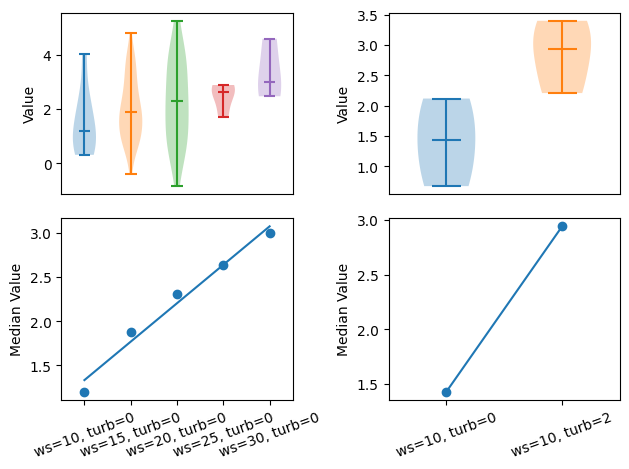

In [4]:
# Intensity
from model import model_train 
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
def plot_result_violin(model, Data, sdec_ckpt_path, dim_vr = 9):
    pilot_train,calm_train,pilot_test = model_train.dataset_generate_test(Data, dim_vr=dim_vr)
    sess=tf.Session()
    sess.run(tf.global_variables_initializer())
    saver = tf.train.Saver(var_list=tf.trainable_variables(), max_to_keep=None)
    saver.restore(sess,sdec_ckpt_path)
    _, _, _, pilot_train_pred_ = model_train.predict_in_sess(model,calm_train,pilot_train, sess,pilot_train)
    pilot_cluster_nums = [np.sum(pilot_train_pred_ == i) for i in range(model.n_cluster)]
    hazard_id = np.argmax(pilot_cluster_nums)
    # _, _, cluster_features_all_, pred_all_ = model_train.predict_in_sess(model,calm_train, pilot_train,sess, unlabeled_data[:10000])
    _, _, pilot_train_cluster_features_ , pilot_train_pred_ = model_train.predict_in_sess(model,calm_train,pilot_train, sess,pilot_train)
    _, _, calm_train_cluster_features_, calm_train_pred_ = model_train.predict_in_sess(model,calm_train,pilot_train, sess,calm_train)
    _, _, pilot_test_cluster_features_, pilot_test_pred_ = model_train.predict_in_sess(model,calm_train,pilot_train, sess,pilot_test)
    # all_hazard_factor = model_train.hazard_factor_calculate(model,cluster_features_all_)
    pilot_test_hazard_factor = model_train.hazard_factor_calculate(model,pilot_test_cluster_features_)
    pilot_train_hazard_factor = model_train.hazard_factor_calculate(model,pilot_train_cluster_features_)
    # mu = np.mean(all_hazard_factor)
    # sigma = np.std(all_hazard_factor)
    # all_hazard_factor_norm = (all_hazard_factor - mu) / sigma    
    # pilot_test_hazard_factor_norm = (pilot_test_hazard_factor - mu) / sigma
    # pilot_train_hazard_factor_norm = (pilot_train_hazard_factor - mu) / sigma
    pilot_test_hazard_factor_norm = pilot_test_hazard_factor
    
    turb_ratio = 8
    pilot_turb_mags = Data.pilot_turb_mags_test
    pilot_ws_mags = Data.pilot_ws_mags_test
    pilot_ws_mags[np.abs(pilot_ws_mags)>30] = 0
    pilot_turb_mags[np.where(np.isnan(pilot_turb_mags))] = 0
    pilot_mags_test = np.abs(pilot_ws_mags)+np.abs(pilot_turb_mags)*turb_ratio
    pilot_turb_mags = Data.pilot_turb_mags_test
    pilot_ws_mags = Data.pilot_ws_mags_test
    pilot_turb_mags[np.where(np.isnan(pilot_turb_mags))] = 0
    pilot_mags = np.vstack((np.abs(pilot_ws_mags.T), np.abs(pilot_turb_mags.T)))
    pilot_mags_unique = np.unique(pilot_mags, axis=1)
    pilot_mags_combine = np.abs(pilot_mags_unique[0,::])+np.abs(pilot_mags_unique[1,::])*turb_ratio
    index_sort = np.argsort(pilot_mags_combine)
    pilot_mags_unique = pilot_mags_unique[::,index_sort]
    pilot_feature_mean = []
    pilot_mag_names = []
    ratio_mags = []
    pilot_violin = []
    # predict_test[predict_test<0.5] = 1
    plt.subplot(221)
    for i_unique_mag in range(pilot_mags_unique.shape[1]):
        index_ws_mag = np.where((np.abs(pilot_ws_mags) == pilot_mags_unique[0, i_unique_mag])
                                & (np.abs(pilot_turb_mags) == pilot_mags_unique[1, i_unique_mag])
                                &(pilot_turb_mags==0))
        if (index_ws_mag[0].shape[0]>2):
            label_for_legend = f'ws={pilot_mags_unique[0,i_unique_mag]}, turb={pilot_mags_unique[1,i_unique_mag]}'
            pilot_feature_mean.append(np.nanmean(pilot_test_hazard_factor_norm[index_ws_mag[0]]))
            pilot_mag_names.append(label_for_legend)
            ratio_mags.append(np.percentile(pilot_test_hazard_factor_norm[index_ws_mag[0]],50))
            plt.violinplot(pilot_test_hazard_factor_norm[index_ws_mag[0]], [len(pilot_mag_names) - 1], showmedians=True)  #
            pilot_violin.append(pilot_test_hazard_factor_norm[index_ws_mag[0]])
    plt.xticks(())
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    plt.ylabel('Value')
    plt.subplot(223)
    
    print((ratio_mags))
    plt.scatter(np.arange(len(pilot_mag_names)), ratio_mags,  marker='o')
    plt.plot(np.arange(len(pilot_mag_names)), fit(np.arange(len(pilot_mag_names)),ratio_mags), '-')
    plt.xticks(np.arange(len(pilot_mag_names)), (pilot_mag_names), rotation=20)
    plt.ylabel('Median Value')
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))

    pilot_feature_mean = []
    pilot_mag_names = []
    ratio_mags = []
    pilot_violin = []
    # 
    plt.subplot(222)
    for i_unique_mag in range(pilot_mags_unique.shape[1]):
        index_ws_mag = np.where((np.abs(pilot_ws_mags) == pilot_mags_unique[0, i_unique_mag])
                                & (np.abs(pilot_turb_mags) == pilot_mags_unique[1, i_unique_mag])
                                &(((pilot_turb_mags==0)&(pilot_ws_mags==10))|((np.abs(pilot_turb_mags)==2)&(np.abs(pilot_ws_mags)==10))))
        if (index_ws_mag[0].shape[0]>2):
            label_for_legend = f'ws={pilot_mags_unique[0,i_unique_mag]}, turb={pilot_mags_unique[1,i_unique_mag]}'
            pilot_feature_mean.append(np.nanmean(pilot_test_hazard_factor_norm[index_ws_mag[0]]))
            pilot_mag_names.append(label_for_legend)
            ratio_mags.append(np.percentile(pilot_test_hazard_factor_norm[index_ws_mag[0]],50))
            plt.violinplot(pilot_test_hazard_factor_norm[index_ws_mag[0]], [len(pilot_mag_names) - 1], showmedians=True)  #
            pilot_violin.append(pilot_test_hazard_factor_norm[index_ws_mag[0]])
    plt.xticks(())
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    plt.ylabel('Value')
    plt.subplot(224)
    plt.scatter(np.arange(len(pilot_mag_names)), ratio_mags,  marker='o')
    plt.plot(np.arange(len(pilot_mag_names)), fit(np.arange(len(pilot_mag_names)),ratio_mags), '-')
    plt.xticks(np.arange(len(pilot_mag_names)), (pilot_mag_names), rotation=20)
    plt.ylabel('Median Value')
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    plt.tight_layout() 
    return pilot_test_hazard_factor
pilot_test_hazard_factor = plot_result_violin(model, Data, sdec_ckpt_path, dim_vr = 9)
plt.savefig('./paper_related/intensity_new_new.pdf')
plt.savefig('./paper_related/intensity_new_new.png')

[0.20636255300777037, 0.1976731463822993, 0.22691345757084536, 0.20347727330556944, 0.24350580137321948]
[0.2201328567263142, 0.21567077322481454, 0.25923861806634985, 0.5839934609560931, 0.7491626106483129]
[0.005464008244011007, 0.011137938098195906, 0.01634122096969564, 0.047014668387368466, 0.028590523754051966]
[1.20362034992187, 1.8741013470252383, 2.313358403687211, 2.635270174098345, 2.998090783189504]


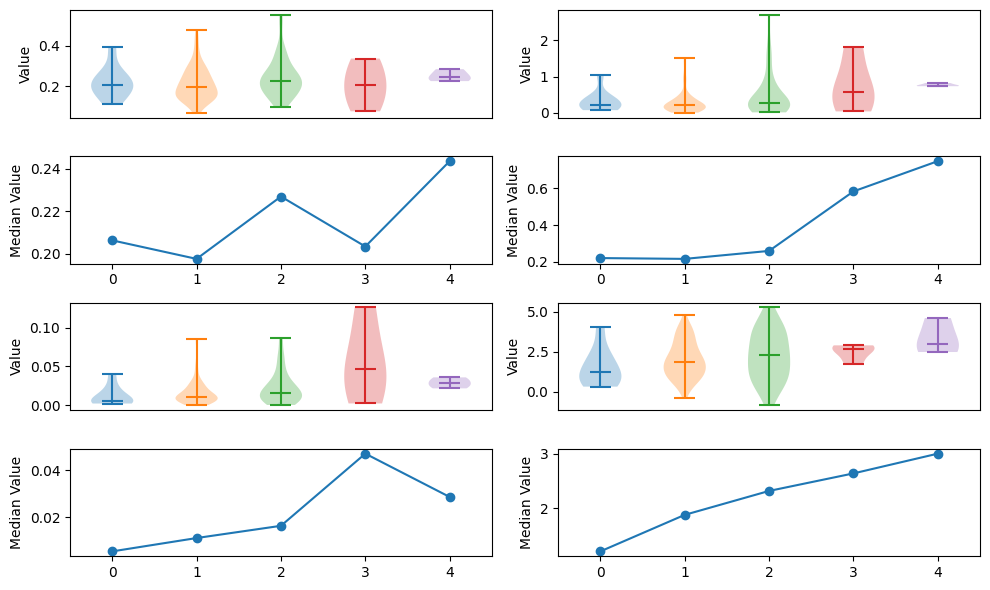

In [ ]:
# Intensity of S factor and EDR
from traditional_methods import traditional_methods
from model import model_train 
from scipy import stats
def fit(x,y):
    coefficients = np.polyfit(x, y, 1)# 进行线性拟合（1 表示一次多项式，即直线）
    poly = np.poly1d(coefficients)  # 生成多项式对象
    return poly(x)
def mann_kendall_trend_test(sequence):
    """Mann-Kendall趋势检验"""
    n = len(sequence)
    
    # 计算S统计量
    s = 0
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(sequence[j] - sequence[i])
    
    # 计算方差（考虑结的情况）
    var_s = n*(n-1)*(2*n+5)/18.0
    
    # 计算Z值
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # 计算p值（双侧检验）
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return z, p, s
_,_,pilot_test = model_train.dataset_generate_test(Data, dim_vr=9)
idx = 5#np.arange(5-1//2,6+1//2,1)
test_x = np.vstack((pilot_test[...,idx]))
test_y = np.hstack((np.zeros(pilot_test.shape[0]) + 1))
trad_test_ = traditional_methods(test_x,test_y)
edr_sampling_ = trad_test_.edr_sampling_scale()
f_factor_ = trad_test_.f_factor()
s_factor_ = trad_test_.s_factor()
turb_ratio = 8
pilot_turb_mags = Data.pilot_turb_mags_test
pilot_ws_mags = Data.pilot_ws_mags_test
pilot_ws_mags[np.abs(pilot_ws_mags)>30] = 0
pilot_turb_mags[np.where(np.isnan(pilot_turb_mags))] = 0
pilot_mags_test = np.abs(pilot_ws_mags)+np.abs(pilot_turb_mags)*turb_ratio
pilot_turb_mags = Data.pilot_turb_mags_test
pilot_ws_mags = Data.pilot_ws_mags_test
pilot_turb_mags[np.where(np.isnan(pilot_turb_mags))] = 0
pilot_mags = np.vstack((np.abs(pilot_ws_mags.T), np.abs(pilot_turb_mags.T)))
pilot_mags_unique = np.unique(pilot_mags, axis=1)
pilot_mags_combine = np.abs(pilot_mags_unique[0,::])+np.abs(pilot_mags_unique[1,::])*turb_ratio
index_sort = np.argsort(pilot_mags_combine)
pilot_mags_unique = pilot_mags_unique[::,index_sort]

def plot_result_violin_trad(factor_value,i):
    pilot_feature_mean = []
    pilot_mag_names = []
    ratio_mags = []
    pilot_violin = []
    plt.subplot(4,2,1+i)
    for i_unique_mag in range(pilot_mags_unique.shape[1]):
        index_ws_mag = np.where((np.abs(pilot_ws_mags) == pilot_mags_unique[0, i_unique_mag])
                                & (np.abs(pilot_turb_mags) == pilot_mags_unique[1, i_unique_mag])
                                &(pilot_turb_mags==0))
        if (index_ws_mag[0].shape[0]>2):
            label_for_legend = f'ws={pilot_mags_unique[0,i_unique_mag]}, turb={pilot_mags_unique[1,i_unique_mag]}'
            pilot_feature_mean.append(np.nanmean(factor_value[index_ws_mag[0]]))
            pilot_mag_names.append(label_for_legend)
            ratio_mags.append(np.percentile(factor_value[index_ws_mag[0]],50))
            plt.violinplot(factor_value[index_ws_mag[0]], [len(pilot_mag_names) - 1], showmedians=True)  #
            pilot_violin.append(factor_value[index_ws_mag[0]])
    plt.xticks(())
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    plt.ylabel('Value')
    plt.subplot(4,2,3+i)
    plt.plot(np.arange(len(pilot_mag_names)), ratio_mags,  'o-')
    print(ratio_mags)
    # plt.plot(np.arange(len(pilot_mag_names)), fit(np.arange(len(pilot_mag_names)),ratio_mags), '-')
    # plt.xticks(np.arange(len(pilot_mag_names)), (pilot_mag_names), rotation=20)
    # plt.ylabel('Median Value')
    plt.xlim((-0.5, len(pilot_mag_names) - 0.5))

    # pilot_feature_mean = []
    # pilot_mag_names = []
    # ratio_mags = []
    # pilot_violin = []
    # # 
    # for i_unique_mag in range(pilot_mags_unique.shape[1]):
    #     index_ws_mag = np.where((np.abs(pilot_ws_mags) == pilot_mags_unique[0, i_unique_mag])
    #                             & (np.abs(pilot_turb_mags) == pilot_mags_unique[1, i_unique_mag])
    #                             &(((pilot_turb_mags==0)&(pilot_ws_mags==10))|((np.abs(pilot_turb_mags)==2)&(np.abs(pilot_ws_mags)==10))))
    #     if (index_ws_mag[0].shape[0]>2):
    #         label_for_legend = f'ws={pilot_mags_unique[0,i_unique_mag]}, turb={pilot_mags_unique[1,i_unique_mag]}'
    #         pilot_feature_mean.append(np.nanmean(edr_sampling_[index_ws_mag[0]]))
    #         pilot_mag_names.append(label_for_legend)
    #         ratio_mags.append(np.percentile(edr_sampling_[index_ws_mag[0]],50))
    #         pilot_violin.append(edr_sampling_[index_ws_mag[0]])
    # plt.xticks(())
    # plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    # plt.ylabel('Value')
    # plt.subplot(122)
    # plt.scatter(np.arange(len(pilot_mag_names)), ratio_mags,  marker='o')
    # plt.plot(np.arange(len(pilot_mag_names)), fit(np.arange(len(pilot_mag_names)),ratio_mags), '-')
    # plt.xticks(np.arange(len(pilot_mag_names)), (pilot_mag_names), rotation=20)
    plt.ylabel('Median Value')
    # plt.xlim((-0.5, len(pilot_mag_names) - 0.5))
    # plt.tight_layout() 
plt.figure(figsize=(10,6))
plot_result_violin_trad(f_factor_,i=0)
plot_result_violin_trad(s_factor_,i=1)
plot_result_violin_trad(edr_sampling_,i=4)
plot_result_violin_trad(pilot_test_hazard_factor,i=5)
plt.tight_layout() 
# plt.savefig('./paper_related/intensity_trad.pdf')
# plt.savefig('./paper_related/intensity_trad.png')

In [165]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# 你的数据
data1 = [0.20636255300777037, 0.1976731463822993, 0.22691345757084536, 0.20347727330556944, 0.24350580137321948]
data2 = [0.2201328567263142, 0.21567077322481454, 0.25923861806634985, 0.5839934609560931, 0.7491626106483129]
data3 = [0.005464008244011007, 0.011137938098195906, 0.01634122096969564, 0.047014668387368466, 0.028590523754051966]
data4 = [1.20362034992187, 1.8741013470252383, 2.313358403687211, 2.635270174098345, 2.998090783189504]

# 先分别归一化，再计算这种NRMSE
def normalized_nrmse(y_true, y_pred):
    # 分别归一化到[0,1]
    y_true_norm = (y_true - np.min(y_true)) / (np.max(y_true) - np.min(y_true))
    y_pred_norm = (y_pred - np.min(y_pred)) / (np.max(y_pred) - np.min(y_pred))
    
    # 然后计算NRMSE
    mse = np.mean((y_pred_norm - y_true_norm) ** 2)
    var = np.var(y_true_norm)
    return np.sqrt(mse / var) if var != 0 else float('inf')
# 计算所有组
metrics = {}
x = np.array([10, 15, 20, 25, 30])
for i, data in enumerate([data1, data2, data3, data4], 1):
    # 标准化数据
    data = np.array(data)
    spearman_rho, spearman_p = stats.spearmanr(x, data)
    print(f"Spearman rho = {spearman_rho:.3f}")
    print(f'NRMSE = {normalized_nrmse(x, data):.3f}')
    # print(f'{symmetric_mape(x, data)}')

Spearman rho = 0.500
NRMSE = 0.900
Spearman rho = 0.900
NRMSE = 0.621
Spearman rho = 0.900
NRMSE = 0.725
Spearman rho = 1.000
NRMSE = 0.225


In [166]:
def linear_regression_metrics(y_true, y_pred):
    """计算线性回归相关指标"""
    # 线性回归
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_pred,y_true)
    
    # 计算R²
    r_squared = r_value ** 2
    
    # 计算调整R²（考虑样本量）
    n = len(y_true)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - 2)
    
    return {
        'slope': slope,              # 斜率
        'intercept': intercept,      # 截距
        'r_squared': r_squared,      # 决定系数
        'adj_r_squared': adj_r_squared,  # 调整决定系数
        'p_value': p_value,          # 显著性
        'std_err': std_err          # 标准误
    }
linear_regression_metrics(x,data4)

{'slope': 11.222486656688815,
 'intercept': -4.744328533996772,
 'r_squared': 0.9763809598330531,
 'adj_r_squared': 0.9685079464440708,
 'p_value': 0.0015516291462405035,
 'std_err': 1.0077433520097492}

In [3]:
# Attention map & reported position (attn-pos模型）
#下载训练好的模型
import  tensorflow.compat.v1 as tf
tf.disable_eager_execution()
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
import os
os.environ["OMP_NUM_THREADS"] = '4'
# os.environ['TF_DETERMINISTIC_OPS'] = '1'
# os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
import scipy.io as scio
from sklearn.metrics import roc_curve, auc
import numpy as np
import random
from scipy.interpolate import interp1d
import math
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from Data.tools import *
from sklearn.manifold import TSNE
import sklearn.svm as svm
from sklearn.metrics import auc,roc_curve
from model_evaluation import *
from Data.Data_import import data_frame
from model.network_build import cluster_NN_v_multi_attn_cnn
from model.model_train import train,test,predict_in_sess,hazard_factor_calculate
from model import model_train 
from palettable.colorbrewer.sequential import Purples_3
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import LinearSegmentedColormap
Data = data_frame(is_all_data=False)
colors_purple = ['#FFFFFF', "#e0d2e7"]  # 白色到深紫色#B29DC5
purple_cmap = LinearSegmentedColormap.from_list('white_to_purple', ['#FFFFFF', "#B29DC5"], N=256)
def normalize_01(x):
    return (x-x.min())/(x.max()-x.min())
def attention_visualize_each(attens_learnt,v_r_mid,title,phy_and_pilot_,phy_f,phy_edr,pos_reported):
    x_interpolated = np.linspace(np.min(np.arange(attens_learnt.shape[0])),
                                 np.max(np.arange(attens_learnt.shape[0]))+1, 128)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, attens_learnt, kind='nearest', fill_value='extrapolate')

    plt.figure(figsize=(8,4))
    plt.subplot(211)
    plt.pcolormesh(np.linspace(0, 128, 129), [min(v_r_mid), max(v_r_mid)],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    plt.plot(np.arange(0, 128, 1), v_r_mid,
             linewidth=1.5)
    plt.scatter(pos_reported,v_r_mid[pos_reported],marker='^',c='C1')
    plt.title(title)
    # plt.ylabel('Radial velocity (Mid sight) (m/s)')
    # plt.yticks((round(min(v_r_mid),2),round(max(v_r_mid),2)))
    plt.subplot(212)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, phy_and_pilot_, kind='nearest', fill_value='extrapolate')
    plt.pcolormesh(np.linspace(0, 128, 129), [0, 1.05],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    plt.plot(normalize_01(phy_f),
             label='Windshear intensity')
    plt.plot(normalize_01(phy_edr),
             label='Turbulent intensity')
    plt.legend()
    plt.xticks([0,32,64,96,128],[0,1500,3000,4500,6000])
    plt.xlabel('Distance to touchdown site (m)')
    plt.ylim((0,1.05))
    plt.yticks((0,0.5,1))
    plt.tight_layout()
    plt.savefig(f'./article/{title}.png')
    # plt.savefig(f'./paper_related/{title}.pdf')
    plt.close()
def attention_visualize_all(attens_learnt,v_r_mid,title,phy_and_pilot_,phy_f,phy_edr,pos_reported,nrow=4,ncol=2,i=1):
    x_interpolated = np.linspace(np.min(np.arange(attens_learnt.shape[0])),
                                 np.max(np.arange(attens_learnt.shape[0]))+1, 128)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, attens_learnt, kind='nearest', fill_value='extrapolate')

    
    plt.subplot(nrow,ncol,i)
    plt.pcolormesh(np.linspace(0, 128, 129), [min(v_r_mid), max(v_r_mid)],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    plt.plot(np.arange(0, 128, 1), v_r_mid,
             linewidth=1.5)
    plt.scatter(pos_reported,v_r_mid[pos_reported],marker='^',c='C1')
    plt.title(title)
    # plt.ylabel('Radial velocity (Mid sight) (m/s)')
    # plt.yticks((round(min(v_r_mid),2),round(max(v_r_mid),2)))
    plt.subplot(nrow,ncol,i+ncol)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, phy_and_pilot_, kind='nearest', fill_value='extrapolate')
    plt.pcolormesh(np.linspace(0, 128, 129), [0, 1.05],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    plt.plot(normalize_01(phy_f),
             label='Windshear intensity')
    plt.plot(normalize_01(phy_edr),
             label='Turbulent intensity')
    plt.legend()
    plt.xticks([0,32,64,96,128],[0,1500,3000,4500,6000])
    # plt.xlabel('Distance to touchdown site (m)')
    plt.ylim((0,1.05))
    plt.yticks((0,0.5,1))
    
def compute_cosine_similarity(pos_SGG,attn_learnt):
    pos_learnt = np.mean(attn_learnt,axis = (1,2))
    cos_sim_s = []
    # 你的数据
    for i in range(pos_SGG.shape[0]):
        true_pos = pos_SGG[i,::].reshape(1, -1)  # 需要reshape成2D
        pred_pos = pos_learnt[i,::].reshape(1, -1)

        # 计算余弦相似度
        cos_sim_i = cosine_similarity(true_pos, pred_pos)
        # print(f"余弦相似度: {cos_sim_i[0][0]:.6f}")
        cos_sim_s.append(cos_sim_i[0][0])
    # plt.plot(cos_sim_s)
    # print(np.mean(cos_sim_s))
    return cos_sim_s
def plot_attn(v_data,attn_learnt,pos_SGG,idx_name,pos_report, turb_report, ws_report,time,visualize_idxs = None):
    ti_series,fi_series = model_train.calculate_turbulence_intensity(v_data,window_size=30)
    pos_learnt = np.mean(attn_learnt,axis = (1,2))
    pos_learnt_top = np.argmax(pos_learnt,axis = 1)
    if visualize_idxs == None:
        for visualize_idx in np.where(pos_learnt_top==np.argmax(pos_SGG,axis=1))[0]:
            title = f'{idx_name}, {visualize_idx}, report_pos_ = {pos_report[visualize_idx]},\
            report turb intens={turb_report[visualize_idx]},report ws intens={ws_report[visualize_idx]},\
            time={time[visualize_idx]} '
            attention_visualize_each(pos_learnt[visualize_idx,::],v_data[visualize_idx,...],title, phy_and_pilot_ = pos_SGG[visualize_idx,::],phy_f = fi_series[visualize_idx,::],phy_edr = ti_series[visualize_idx,::],pos_reported = pos_report[visualize_idx])
    elif len(visualize_idxs)==4:
        plt.figure(figsize=(13,7))
        ax_idx = [1,2,5,6]
        for i,visualize_idx in enumerate(visualize_idxs):#np.where(pos_learnt_top==np.argmax(pos_SGG,axis=1))[0]:
            # title = f'{idx_name}, {visualize_idx}, report_pos_ = {pos_report[visualize_idx]},\
            # report turb intens={turb_report[visualize_idx]},report ws intens={ws_report[visualize_idx]},\
            # time={time[visualize_idx]} '
            title = f'{idx_name} , {visualize_idx}'
            # attention_visualize_each(pos_learnt[visualize_idx,::],v_data[visualize_idx,...],title, phy_and_pilot_ = pos_SGG[visualize_idx,::],phy_f = fi_series[visualize_idx,::],phy_edr = ti_series[visualize_idx,::],pos_reported = pos_report[visualize_idx])
            attention_visualize_all(pos_learnt[visualize_idx,::],v_data[visualize_idx,...],title, phy_and_pilot_ = pos_SGG[visualize_idx,::],phy_f = fi_series[visualize_idx,::],phy_edr = ti_series[visualize_idx,::],pos_reported = pos_report[visualize_idx],nrow=4,ncol=2,i=ax_idx[i])
            plt.tight_layout()
        plt.savefig(f'./paper_related/{idx_name}.png')
        plt.savefig(f'./paper_related/{idx_name}.pdf')
        plt.close()
        # plt.show()
    else:
        for i,visualize_idx in enumerate(visualize_idxs):
            title = f'{idx_name} , {visualize_idx}'
            
            attention_visualize_each(pos_learnt[visualize_idx,::],v_data[visualize_idx,...],title, phy_and_pilot_ = pos_SGG[visualize_idx,::],phy_f = fi_series[visualize_idx,::],phy_edr = ti_series[visualize_idx,::],pos_reported = pos_report[visualize_idx])
            
    

In [4]:
tf.reset_default_graph()
sdec_ckpt_path = os.path.join('sdec_ckpt', 'cnn-attn-pos_supervise.ckpt')#_attn_pos
Is_pos = True
pilot_train,calm_train,pilot_test = model_train.dataset_generate_test(Data, dim_vr=9)
model = cluster_NN_v_multi_attn_cnn(a = 1, b=30, c = 3, d= 40,  attn_loc = '4',head_num=1,If_pos=Is_pos,f=500)
# AUCs,CSIs = test(model,Data,sdec_ckpt_path) #Test the auc and csi
# print(AUCs,CSIs)         
sess=tf.Session()
sess.run(tf.global_variables_initializer())
saver = tf.train.Saver(var_list=tf.trainable_variables(), max_to_keep=None)
saver.restore(sess,sdec_ckpt_path)
pilot_train_attn = sess.run(model.attn_output,feed_dict = {model.input: pilot_train,
                                                 model.input_batch_size: pilot_train.shape[0]})
pilot_test_attn = sess.run(model.attn_output,feed_dict = {model.input: pilot_test,
                                                 model.input_batch_size: pilot_test.shape[0]})
sess.close()
percent = 90
window_size = 30
phy_test = model_train.cal_t_f(pilot_test[...,4],percent,window_size)
phy_rep_test = model_train.attn_pos_set(phy_test,Data.hazard_position_test)
phy_train = model_train.cal_t_f(pilot_train[...,4],percent,window_size)
phy_rep_train = model_train.attn_pos_set(phy_train,Data.hazard_position_train)
report_pos_test = np.where(Data.hazard_position_test==1)[1]
report_pos_train = np.where(Data.hazard_position_train==1)[1]
report_pos_test_top = np.floor(report_pos_test/32)
report_pos_train_top = np.floor(report_pos_train/32)

idx_name = 'train'
turb_report = Data.pilot_turb_mag_train
ws_report = Data.pilot_ws_mag_train
pos_SGG = phy_rep_train
time = Data.pilot_train_time
pos_report = report_pos_train
attn_learnt = pilot_train_attn
v_data = pilot_train[...,4]
cos_sim_s = compute_cosine_similarity(pos_SGG,attn_learnt)
print(f"train:=========cosine similarity:{np.mean(cos_sim_s)}=============")
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pos_learnt_top = np.argmax(pos_learnt,axis = 1)
print(f"train:=========Top consistent number:{np.sum(pos_learnt_top==np.argmax(pos_SGG,axis=1))}")
# plot_attn(v_data,attn_learnt,pos_SGG,idx_name,pos_report, turb_report, ws_report,time,visualize_idxs=[16,27,39,47,49,51,70,78])#0,12,79,83,99
idx_name = 'test'
turb_report = Data.pilot_turb_mags_test
ws_report = Data.pilot_ws_mags_test
pos_SGG = phy_rep_test
time = Data.pilot_test_time
pos_report = report_pos_test
attn_learnt = pilot_test_attn
v_data = pilot_test[...,4]
cos_sim_s = compute_cosine_similarity(pos_SGG,attn_learnt)
print(f"test:=========cosine similarity:{np.mean(cos_sim_s)}=============")
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pos_learnt_top = np.argmax(pos_learnt,axis = 1)
print(f"test:=========Top consistent number:{np.sum(pos_learnt_top==np.argmax(pos_SGG,axis=1))}")
# plot_attn(v_data,attn_learnt,pos_SGG,idx_name,pos_report, turb_report, ws_report,time,visualize_idxs=[80,99,107,115,133])##0,47,51,52,57,65,79,127,134,135

INFO:tensorflow:Restoring parameters from sdec_ckpt\cnn-attn-pos_supervise.ckpt
train:=========cosine similarity:0.8332807802301831=============
train:=========Top consistent number:121
test:=========cosine similarity:0.7190991658876941=============
test:=========Top consistent number:103


In [47]:
'''估计位置与SGG不一致的，反演出二维风场，检查估计出的位置是否更准确'''
import Ridge_decompose2D_hazard_verify
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
import scipy.io as scio
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from Data.tools import *
from model_evaluation import *
from Data.Data_import import data_frame
from model.network_build import cluster_NN_v_multi_attn_cnn
from model import model_train 
from matplotlib.colors import LinearSegmentedColormap
corridor_polar_coordinates = scio.loadmat('corridor_polar_coordinates.mat')#二维风速对应的极坐标，用于反演风场
def plot_wind_retrieve(ax,visualize_idx,v_r_multi,coridor_r_multi,corridor_azimuth_multi):
    
    # ====== 关键修改：统一维度顺序 ======
    # 转置数据使其符合你的绘图期望
    corridor_azimuth_multi = corridor_azimuth_multi.T  # 如果原始是(11,128)，转置为(128,11)
    coridor_r_multi = coridor_r_multi.T

    # 现在保存转置后的形状
    original_shape = corridor_azimuth_multi.shape  # 比如 (128, 11)

    # 处理数据
    u_hat, v_hat, v_r_error, weight = Ridge_decompose2D_hazard_verify.wind_retrieval2D_main_xy_adaptive_lr(
        coridor_r_multi.reshape(-1,1), corridor_azimuth_multi.reshape(-1,1),  v_r_multi.reshape(-1,1), 3)

    # 恢复形状
    u_hat = u_hat.reshape(original_shape)
    v_hat = v_hat.reshape(original_shape)

    # 计算坐标
    corridor_x_retrieve = np.sin(corridor_azimuth_multi) * coridor_r_multi
    corridor_y_retrieve = np.cos(corridor_azimuth_multi) * coridor_r_multi

    # 创建网格
    x, y = np.meshgrid(np.arange(original_shape[1]), np.arange(original_shape[0]))
    v_r_retrieved = u_hat * np.sin(corridor_azimuth_multi) + v_hat * np.cos(corridor_azimuth_multi)

    im = ax.pcolor(v_r_multi.T,cmap='Spectral_r')
    # plt.colorbar()
    step = 10
    ax.quiver(y[::step, ::2],x[::step, ::2],  u_hat[::step, ::2], v_hat[::step, ::2],scale=350, width=0.003)
    # ax.set_title(f'Retrieved wind vectors,RMSE={np.mean((v_r_multi - v_r_retrieved)**2):.2f}')
    return im
Data = data_frame(is_all_data=False)
colors_purple = ['#FFFFFF', "#e0d2e7"]  # 白色到深紫色#B29DC5
purple_cmap = LinearSegmentedColormap.from_list('white_to_purple', ['#FFFFFF', "#B29DC5"], N=256)

def attention_visualize_each_ax(attens_learnt,v_r_mid,title,phy_and_pilot_,phy_f,phy_edr,pos_reported,axes):
    x_interpolated = np.linspace(np.min(np.arange(attens_learnt.shape[0])),
                                 np.max(np.arange(attens_learnt.shape[0]))+1, 128)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, attens_learnt, kind='nearest', fill_value='extrapolate')

    
    axes[0].pcolormesh(np.linspace(0, 128, 129), [min(v_r_mid), max(v_r_mid)],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    axes[0].plot(np.arange(0, 128, 1), v_r_mid,
             linewidth=1.5)
    axes[0].scatter(pos_reported,v_r_mid[pos_reported],marker='^',c='C1')
    # axes[0].set_title(title)
    # plt.ylabel('Radial velocity (Mid sight) (m/s)')
    # plt.yticks((round(min(v_r_mid),2),round(max(v_r_mid),2)))
    # plt.subplot(212)
    f = interp1d(np.arange(attens_learnt.shape[0])+0.5, phy_and_pilot_, kind='nearest', fill_value='extrapolate')
    axes[1].pcolormesh(np.linspace(0, 128, 129), [0, 1.05],f(x_interpolated).reshape(1, -1), 
                   cmap=purple_cmap,shading='flat')#Purples_3.mpl_colormap
    axes[1].plot(normalize_01(phy_f),
             label='Windshear intensity')
    axes[1].plot(normalize_01(phy_edr),
             label='Turbulent intensity')
    axes[1].legend()
    axes[1].set_xticks([0,32,64,96,128],[0,1500,3000,4500,6000])
    axes[1].set_xlabel('Distance to touchdown site (m)')
    axes[1].set_ylim((0,1.05))
    axes[1].set_yticks((0,0.5,1))
    # axes[1].set_tight_layout()
    # axes[1].set_savefig(f'./article/{title}.png')
    # plt.savefig(f'./paper_related/{title}.pdf')
    # plt.close()


def plot_wind_field_and_position_estimation(idx_name,v_data_2d,pilot_loc_3or4,pos_learnt,pos_SGG,pos_report,visualize_idxs,time):
    v_data = v_data_2d[...,5]
    for i,visualize_idx in enumerate(visualize_idxs):
        v_r_multi = v_data_2d[visualize_idx,...]
        if pilot_loc_3or4[visualize_idx,0]==3:
            coridor_r_multi = corridor_polar_coordinates['coridor_r_multi_loc3']
            corridor_azimuth_multi = corridor_polar_coordinates['corridor_azimuth_multi_loc3']
        else:
            coridor_r_multi = corridor_polar_coordinates['coridor_r_multi_loc4']
            corridor_azimuth_multi = corridor_polar_coordinates['corridor_azimuth_multi_loc4']
        plt.figure(figsize = (12,10))
        fig, (ax0, ax1,ax2) = plt.subplots(3,1)
        im1 = plot_wind_retrieve(ax0,visualize_idx,v_r_multi,coridor_r_multi,corridor_azimuth_multi)
        my_title = f'{idx_name} , {visualize_idx},{time[visualize_idx]}'
        ti_series,fi_series = model_train.calculate_turbulence_intensity(v_data,window_size=30)
        attention_visualize_each_ax(pos_learnt[visualize_idx,::],v_data[visualize_idx,...],my_title, phy_and_pilot_ = pos_SGG[visualize_idx,::],phy_f = fi_series[visualize_idx,::],phy_edr = ti_series[visualize_idx,::],pos_reported = pos_report[visualize_idx],axes=[ax1,ax2])
        fig.colorbar(im1, ax=ax0, orientation='horizontal',location='top',extend='both')
        plt.tight_layout()
        plt.savefig(f'./paper_related/{my_title}.pdf')
        # plt.show()            
    

d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\sklearn\linear_model\_base.py:155: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.
  FutureWarning,
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\sklearn\linear_model\_base.py:155: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.
  FutureWarning,
d:\Programfiles\Anaconda\envs\tf_gpu\lib\site-packages\sklearn\linear_model\_base.py:155: FutureWarning: 'normalize' was deprecated in versi

<Figure size 1200x1000 with 0 Axes>

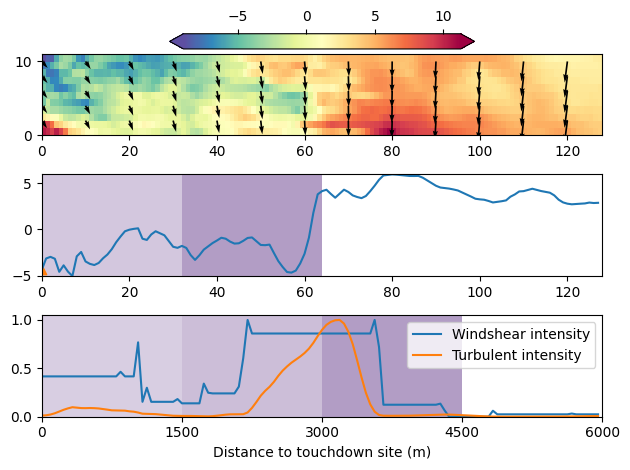

In [49]:
'''画出与SGG 对不上的结果的pcolor，检查是不是attention map是对的，而SGG不对'''
idx_name = 'train'
turb_report = Data.pilot_turb_mag_train
ws_report = Data.pilot_ws_mag_train
pos_SGG = phy_rep_train
time = Data.pilot_train_time
pos_report = report_pos_train
attn_learnt = pilot_train_attn
v_data_2d = Data.pilot_train
visualize_idxs=[51]#51,27,39,78
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pilot_loc_3or4 = Data.pilot_train_loc_3or4
plot_wind_field_and_position_estimation(idx_name,v_data_2d,pilot_loc_3or4,pos_learnt,pos_SGG,pos_report,visualize_idxs,time)
idx_name = 'test'
turb_report = Data.pilot_turb_mags_test
ws_report = Data.pilot_ws_mags_test
pos_SGG = phy_rep_test
time = Data.pilot_test_time
pos_report = report_pos_test
attn_learnt = pilot_test_attn
v_data_2d = Data.pilot_test
visualize_idxs=[99]#,107,115,133
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pilot_loc_3or4 = Data.pilot_test_loc_3or4
# plot_wind_field_and_position_estimation(idx_name,v_data_2d,pilot_loc_3or4,pos_learnt,pos_SGG,pos_report,visualize_idxs,time)

In [39]:
tf.reset_default_graph()
sdec_ckpt_path = os.path.join('sdec_ckpt', 'cnn-attn_supervise.ckpt')#_attn_pos
Is_pos = False
pilot_train,calm_train,pilot_test = model_train.dataset_generate_test(Data, dim_vr=9)
model = cluster_NN_v_multi_attn_cnn(a = 1, b=30, c = 3, d= 40,  attn_loc = '4',head_num=1,If_pos=Is_pos,f=500)
AUCs,CSIs = test(model,Data,sdec_ckpt_path) #Test the auc and csi
print(AUCs,CSIs)         
   
sess=tf.Session()
sess.run(tf.global_variables_initializer())
saver = tf.train.Saver(var_list=tf.trainable_variables(), max_to_keep=None)
saver.restore(sess,sdec_ckpt_path)
pilot_train_attn = sess.run(model.attn_output,feed_dict = {model.input: pilot_train,
                                                 model.input_batch_size: pilot_train.shape[0]})
pilot_test_attn = sess.run(model.attn_output,feed_dict = {model.input: pilot_test,
                                                 model.input_batch_size: pilot_test.shape[0]})
sess.close()
percent = 90
window_size = 30
phy_test = model_train.cal_t_f(pilot_test[...,4],percent,window_size)
phy_rep_test = model_train.attn_pos_set(phy_test,Data.hazard_position_test)
phy_train = model_train.cal_t_f(pilot_train[...,4],percent,window_size)
phy_rep_train = model_train.attn_pos_set(phy_train,Data.hazard_position_train)
report_pos_test = np.where(Data.hazard_position_test==1)[1]
report_pos_train = np.where(Data.hazard_position_train==1)[1]
report_pos_test_top = np.floor(report_pos_test/32)
report_pos_train_top = np.floor(report_pos_train/32)

idx_name = 'train'
turb_report = Data.pilot_turb_mag_train
ws_report = Data.pilot_ws_mag_train
pos_SGG = phy_rep_train
time = Data.pilot_train_time
pos_report = report_pos_train
attn_learnt = pilot_train_attn
v_data = pilot_train[...,4]
cos_sim_s = compute_cosine_similarity(pos_SGG,attn_learnt)
print(f"train:=========cosine similarity:{np.mean(cos_sim_s)}=============")
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pos_learnt_top = np.argmax(pos_learnt,axis = 1)
print(f"train:=========Top consistent number:{np.sum(pos_learnt_top==np.argmax(pos_SGG,axis=1))}")
# plot_attn(v_data,attn_learnt,pos_SGG,idx_name,pos_report, turb_report, ws_report,time,visualize_idxs=[0])#0,12,79,83,99
idx_name = 'test'
turb_report = Data.pilot_turb_mags_test
ws_report = Data.pilot_ws_mags_test
pos_SGG = phy_rep_test
time = Data.pilot_test_time
pos_report = report_pos_test
attn_learnt = pilot_test_attn
v_data = pilot_test[...,4]
cos_sim_s = compute_cosine_similarity(pos_SGG,attn_learnt)
print(f"test:=========cosine similarity:{np.mean(cos_sim_s)}=============")
pos_learnt = np.mean(attn_learnt,axis = (1,2))
pos_learnt_top = np.argmax(pos_learnt,axis = 1)
print(f"test:=========Top consistent number:{np.sum(pos_learnt_top==np.argmax(pos_SGG,axis=1))}")
# plot_attn(v_data,attn_learnt,pos_SGG,idx_name,pos_report, turb_report, ws_report,time,visualize_idxs=[47,65,79,134])##0,47,51,52,57,65,79,127,134,135

INFO:tensorflow:Restoring parameters from sdec_ckpt\cnn-attn_supervise.ckpt
[[0.98552272]] [[0.89570552]]
INFO:tensorflow:Restoring parameters from sdec_ckpt\cnn-attn_supervise.ckpt
train:=========cosine similarity:0.6148078247127702=============
train:=========Top consistent number:74
test:=========cosine similarity:0.6273963062387713=============
test:=========Top consistent number:84
